<a href="https://colab.research.google.com/github/guravharshvardhan/Deep-Learning/blob/main/Experiment_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 93ms/step - accuracy: 0.5241 - loss: 0.6884 - val_accuracy: 0.5460 - val_loss: 0.6772
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 85ms/step - accuracy: 0.6316 - loss: 0.6097 - val_accuracy: 0.5344 - val_loss: 0.7024
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 92ms/step - accuracy: 0.7110 - loss: 0.4671 - val_accuracy: 0.5442 - val_loss: 0.7602
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 86ms/step - accuracy: 0.7473 - loss: 0.3911 - val_accuracy: 0.5308 - val_loss: 0.8608
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 88ms/step - accuracy: 0.7607 - loss: 0.3731 - val_accuracy: 0.5310 - val_loss: 0.9101
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 86ms/step - accuracy: 0.7659 - loss: 0.3596 - val_accuracy: 0.5552 - val_loss: 0.9413
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 86ms/step - accuracy: 0.7829 - loss: 0.3436 - val_accuracy: 0.5620 - val_loss: 0.9207
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step - accuracy: 0.7925 - loss: 0.3283 - 

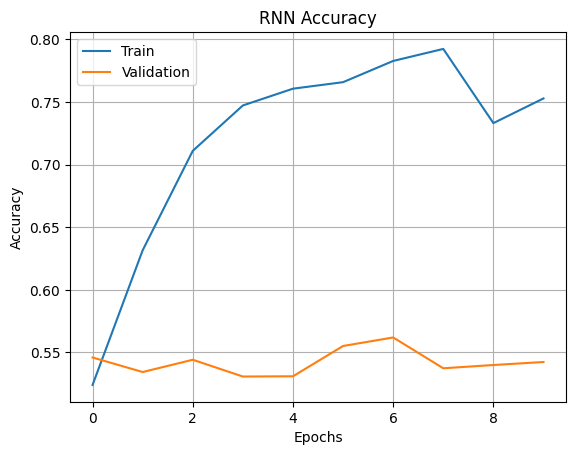

In [ ]:
# ===== RNN MODEL =====

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Embedding

# Reproducibility
np.random.seed(42)

# Load data
vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# Padding
max_len = 200
x_train = pad_sequences(x_train, maxlen=max_len, padding='post')
x_test = pad_sequences(x_test, maxlen=max_len, padding='post')

# Model
model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    SimpleRNN(64, dropout=0.2),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

# Evaluate
loss, acc = model.evaluate(x_test, y_test)
print("RNN Accuracy:", acc)

# Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('RNN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.grid()
plt.show()

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 76s 235ms/step - accuracy: 0.5767 - loss: 0.6643 - val_accuracy: 0.6156 - val_loss: 0.6261
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 236ms/step - accuracy: 0.6625 - loss: 0.5684 - val_accuracy: 0.8400 - val_loss: 0.4937
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 73s 234ms/step - accuracy: 0.7557 - loss: 0.4823 - val_accuracy: 0.8302 - val_loss: 0.4414
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 73s 232ms/step - accuracy: 0.7109 - loss: 0.5583 - val_accuracy: 0.7058 - val_loss: 0.6248
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 88s 251ms/step - accuracy: 0.7390 - loss: 0.5393 - val_accuracy: 0.5618 - val_loss: 0.6510
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 76s 231ms/step - accuracy: 0.7713 - loss: 0.4706 - val_accuracy: 0.8176 - val_loss: 0.4717
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 234ms/step - accuracy: 0.8350 - loss: 0.4154 - val_accuracy: 0.8188 - val_loss: 0.4570
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 72s 231ms/step - accuracy: 0.8806 - loss: 0

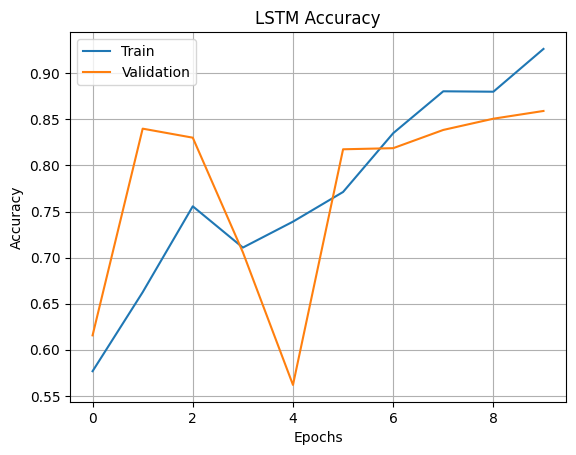

In [ ]:
# ===== LSTM MODEL =====

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding

np.random.seed(42)

# Load data
vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# Padding
max_len = 200
x_train = pad_sequences(x_train, maxlen=max_len, padding='post')
x_test = pad_sequences(x_test, maxlen=max_len, padding='post')

# Model
model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    LSTM(64, dropout=0.2),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

# Evaluate
loss, acc = model.evaluate(x_test, y_test)
print("LSTM Accuracy:", acc)

# Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('LSTM Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.grid()
plt.show()

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 253ms/step - accuracy: 0.5666 - loss: 0.6640 - val_accuracy: 0.6080 - val_loss: 0.6125
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 79s 252ms/step - accuracy: 0.8217 - loss: 0.3983 - val_accuracy: 0.8772 - val_loss: 0.3066
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 79s 252ms/step - accuracy: 0.9169 - loss: 0.2205 - val_accuracy: 0.8898 - val_loss: 0.2718
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 79s 253ms/step - accuracy: 0.9514 - loss: 0.1401 - val_accuracy: 0.8828 - val_loss: 0.3121
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 253ms/step - accuracy: 0.9715 - loss: 0.0881 - val_accuracy: 0.8780 - val_loss: 0.3294
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 254ms/step - accuracy: 0.9822 - loss: 0.0569 - val_accuracy: 0.8748 - val_loss: 0.3965
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 253ms/step - accuracy: 0.9883 - loss: 0.0394 - val_accuracy: 0.8720 - val_loss: 0.4268
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 256ms/step - accuracy: 0.9926 - loss: 0

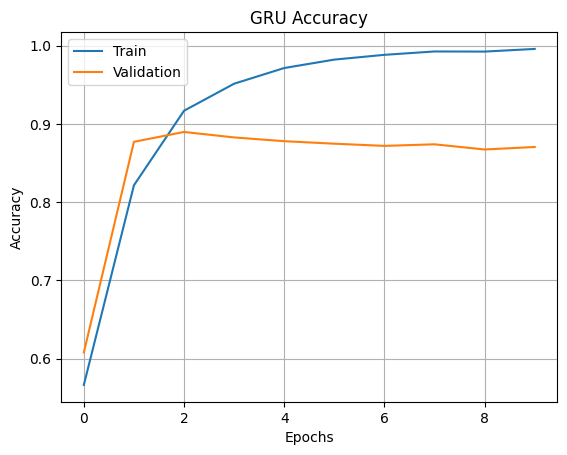

In [ ]:
# ===== GRU MODEL =====

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Embedding

np.random.seed(42)

# Load data
vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# Padding
max_len = 200
x_train = pad_sequences(x_train, maxlen=max_len, padding='post')
x_test = pad_sequences(x_test, maxlen=max_len, padding='post')

# Model
model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    GRU(64, dropout=0.2),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

# Evaluate
loss, acc = model.evaluate(x_test, y_test)
print("GRU Accuracy:", acc)

# Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('GRU Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.grid()
plt.show()